In [1]:
import os
import cv2
import pandas as pd
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Model,load_model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, Input, Concatenate
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, LearningRateScheduler, Callback
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.applications import DenseNet201
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import tensorflow_addons as tfa

c:\Users\Lokesh\anaconda3\envs\radiolytica\lib\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
c:\Users\Lokesh\anaconda3\envs\radiolytica\lib\site-packages\tensorflow_addons\utils\ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.12.0 and strictly below 2.15.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.10.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file a

In [2]:
# Clear GPU memory before starting
def clear_gpu_memory():
    try:
        from numba import cuda
        device = cuda.get_current_device()
        device.reset()
    except:
        pass
    # Clear TensorFlow session
    tf.keras.backend.clear_session()
    # Enable memory growth to prevent TensorFlow from allocating all GPU memory at once
    physical_devices = tf.config.list_physical_devices('GPU')
    if physical_devices:
        for device in physical_devices:
            try:
                tf.config.experimental.set_memory_growth(device, True)
                print(f"Memory growth enabled for GPU device: {device}")
            except:
                print("Error enabling memory growth")

clear_gpu_memory()

Memory growth enabled for GPU device: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [3]:
# Set mixed precision policy for efficiency
try:
    from tensorflow.keras.mixed_precision import set_global_policy
    set_global_policy('mixed_float16')
    print("Mixed precision policy set to mixed_float16")
except:
    print("Couldn't set mixed precision policy")


INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3050 Laptop GPU, compute capability 8.6
Mixed precision policy set to mixed_float16


In [4]:
def process_lung_image(image_path, mask_path=None, target_size=(224, 224)):
    """Enhanced processing for better feature extraction"""
    # Load image with validation
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Could not load image: {image_path}")
        
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Failed to read image: {image_path}")
    
    # Histogram equalization for better contrast
    img = cv2.equalizeHist(img)
    
    # Resize with cubic interpolation for better quality
    img_resized = cv2.resize(img, target_size, interpolation=cv2.INTER_CUBIC)
    
    # Apply mask if available
    if mask_path and os.path.exists(mask_path):
        lung_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask_resized = cv2.resize(lung_mask, target_size)
        # Create a soft mask (not binary)
        mask_normalized = mask_resized / 255.0
        # Apply the lung mask to extract the lung regions
        segmented_lungs = img_resized * mask_normalized
    else:
        segmented_lungs = img_resized
    
    # Apply CLAHE with more appropriate parameters for medical images
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    img_clahe = clahe.apply(segmented_lungs.astype(np.uint8))
    
    # Use Laplacian for better edge enhancement of pneumonia consolidations
    laplacian = cv2.Laplacian(img_clahe, cv2.CV_8U, ksize=3)
    img_enhanced = cv2.addWeighted(img_clahe, 1.0, laplacian, 0.3, 0)
    
    # Gamma correction to enhance subtle features
    gamma = 1.2
    img_gamma = np.array(255 * (img_enhanced / 255) ** gamma, dtype='uint8')
    
    # Normalize to 0-1 range
    img_normalized = img_gamma / 255.0
    
    # Convert to RGB (3 channels)
    img_rgb = np.repeat(img_normalized[:, :, np.newaxis], 3, axis=-1)
    
    return img_rgb

In [5]:
def _augment_function_improved(img, label):
    """Medical-specific augmentation strategy"""
    # Random brightness with smaller delta - medical images are sensitive
    img = tf.image.random_brightness(img, max_delta=0.1)
    
    # Careful with contrast adjustments
    img = tf.image.random_contrast(img, lower=0.9, upper=1.2)
    
    # Horizontal flips only (lungs are roughly symmetrical)
    img = tf.image.random_flip_left_right(img)
    
    # Subtle rotation (X-rays are usually taken in standard positions)
    angle = tf.random.uniform([], -10, 10) * np.pi / 180
    img = tfa.image.rotate(img, angle)
    
    # Careful zoom (don't crop out important regions)
    crop_size = tf.random.uniform([], 0.85, 1.0, dtype=tf.float32)
    img_shape = tf.shape(img)
    img_height, img_width = img_shape[0], img_shape[1]
    crop_height = tf.cast(tf.cast(img_height, tf.float32) * crop_size, tf.int32)
    crop_width = tf.cast(tf.cast(img_width, tf.float32) * crop_size, tf.int32)
    img = tf.image.random_crop(img, [crop_height, crop_width, 3])
    img = tf.image.resize(img, [224, 224])
    
    # Very subtle noise
    noise = tf.random.normal(shape=tf.shape(img), mean=0.0, stddev=0.005)
    img = tf.clip_by_value(img + noise, 0.0, 1.0)
    
    return img, label

In [6]:
def create_tf_dataset_improved(image_paths, mask_paths, labels, batch_size, is_training=False):
    """
    Create an improved tf.data pipeline with better augmentation.
    Args:
        image_paths: List of image file paths.
        mask_paths: List of mask file paths (can be None).
        labels: List of labels (0 for normal, 1 for pneumonia).
        batch_size: Batch size for training.
        is_training: Whether to apply data augmentation.
    Returns:
        tf.data.Dataset object.
    """
    def _process_function(img_path, mask_path, label):
        # Convert tensor to string
        img_path_str = img_path.numpy().decode('utf-8')
        # Handle mask path (could be empty string)
        if tf.strings.length(mask_path) > 0:
            mask_path_str = mask_path.numpy().decode('utf-8')
        else:
            mask_path_str = None
        # Use the process_lung_image function
        processed_img = process_lung_image(img_path_str, mask_path_str)
        # Convert to tensor
        processed_img = tf.convert_to_tensor(processed_img, dtype=tf.float32)
        return processed_img, label

    def _tf_process_function(img_path, mask_path, label):
        # Wrap the function to use tf.py_function
        [processed_img, label] = tf.py_function(
            func=_process_function,
            inp=[img_path, mask_path, label],
            Tout=[tf.float32, tf.float32]
        )
        # Set shape information that gets lost in py_function
        processed_img.set_shape((224, 224, 3))
        label.set_shape(())
        return processed_img, label

    # Handle None values in mask_paths by replacing with empty strings
    mask_paths = ["" if path is None else path for path in mask_paths]

    # Convert lists to tensors
    image_paths = tf.constant(image_paths)
    mask_paths = tf.constant(mask_paths)
    labels = tf.constant(labels, dtype=tf.float32)

    # Create dataset
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths, labels))

    # Apply processing function
    dataset = dataset.map(_tf_process_function, num_parallel_calls=tf.data.AUTOTUNE)

    # Apply augmentation if training
    if is_training:
        dataset = dataset.map(_augment_function_improved, num_parallel_calls=tf.data.AUTOTUNE)

    # Shuffle if training
    if is_training:
        dataset = dataset.shuffle(buffer_size=1000)

    # Batch and prefetch
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return dataset

In [7]:
# CyclicLR implementation for Phase 1
class CyclicLR(tf.keras.callbacks.Callback):
    def __init__(self, base_lr=0.0001, max_lr=0.001, step_size=2000, mode='triangular2', gamma=1., scale_fn=None, scale_mode='cycle'):
        super(CyclicLR, self).__init__()
        self.base_lr = base_lr
        self.max_lr = max_lr
        self.step_size = step_size
        self.mode = mode
        self.gamma = gamma
        if scale_fn is None:
            if self.mode == 'triangular':
                self.scale_fn = lambda x: 1.
                self.scale_mode = 'cycle'
            elif self.mode == 'triangular2':
                self.scale_fn = lambda x: 1 / (2. ** (x - 1))
                self.scale_mode = 'cycle'
            elif self.mode == 'exp_range':
                self.scale_fn = lambda x: gamma ** x
                self.scale_mode = 'iterations'
        else:
            self.scale_fn = scale_fn
            self.scale_mode = scale_mode
        self.clr_iterations = 0.
        self.trn_iterations = 0.
        self.history = {}

    def clr(self):
        cycle = np.floor(1 + self.clr_iterations / (2 * self.step_size))
        x = np.abs(self.clr_iterations / self.step_size - 2 * cycle + 1)
        if self.scale_mode == 'cycle':
            return self.base_lr + (self.max_lr - self.base_lr) * np.maximum(0, (1 - x)) * self.scale_fn(cycle)
        else:
            return self.base_lr + (self.max_lr - self.base_lr) * np.maximum(0, (1 - x)) * self.scale_fn(self.clr_iterations)

    def on_train_begin(self, logs=None):
        logs = logs or {}
        if self.clr_iterations == 0:
            tf.keras.backend.set_value(self.model.optimizer.lr, self.base_lr)
        else:
            tf.keras.backend.set_value(self.model.optimizer.lr, self.clr())

    def on_batch_end(self, batch, logs=None):
        logs = logs or {}
        self.trn_iterations += 1
        self.clr_iterations += 1
        tf.keras.backend.set_value(self.model.optimizer.lr, self.clr())
        self.history.setdefault('lr', []).append(tf.keras.backend.get_value(self.model.optimizer.lr))
        self.history.setdefault('iterations', []).append(self.trn_iterations)
        for k, v in logs.items():
            self.history.setdefault(k, []).append(v)
    
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        logs['lr'] = tf.keras.backend.get_value(self.model.optimizer.lr)


In [8]:
# CLMR: Cyclic Learning Rate and Momentum for Phase 2
class CLMR(tf.keras.callbacks.Callback):
    def __init__(self, base_lr=0.00001, max_lr=0.0001, base_momentum=0.85, max_momentum=0.95, step_size=2000, mode='triangular2'):
        super(CLMR, self).__init__()
        self.base_lr = base_lr
        self.max_lr = max_lr
        self.base_momentum = base_momentum
        self.max_momentum = max_momentum
        self.step_size = step_size
        self.mode = mode
        self.clr_iterations = 0.
        self.trn_iterations = 0.
        self.history = {}

        if self.mode == 'triangular2':
            self.scale_fn = lambda x: 1 / (2. ** (x - 1))
            self.scale_mode = 'cycle'
        else:
            self.scale_fn = lambda x: 1.
            self.scale_mode = 'cycle'

    def clr(self):
        cycle = np.floor(1 + self.clr_iterations / (2 * self.step_size))
        x = np.abs(self.clr_iterations / self.step_size - 2 * cycle + 1)
        if self.scale_mode == 'cycle':
            return self.base_lr + (self.max_lr - self.base_lr) * np.maximum(0, (1 - x)) * self.scale_fn(cycle)
        else:
            return self.base_lr + (self.max_lr - self.base_lr) * np.maximum(0, (1 - x)) * self.scale_fn(self.clr_iterations)
    
    def cyclical_momentum(self):
        cycle = np.floor(1 + self.clr_iterations / (2 * self.step_size))
        x = np.abs(self.clr_iterations / self.step_size - 2 * cycle + 1)
        # Inverse relationship to LR - as LR increases, momentum decreases
        return self.max_momentum - (self.max_momentum - self.base_momentum) * np.maximum(0, (1 - x))

    def on_train_begin(self, logs=None):
        logs = logs or {}
        if self.clr_iterations == 0:
            tf.keras.backend.set_value(self.model.optimizer.lr, self.base_lr)
            if hasattr(self.model.optimizer, 'momentum'):
                tf.keras.backend.set_value(self.model.optimizer.momentum, self.max_momentum)

    def on_batch_end(self, batch, logs=None):
        logs = logs or {}
        self.trn_iterations += 1
        self.clr_iterations += 1
        
        lr = self.clr()
        tf.keras.backend.set_value(self.model.optimizer.lr, lr)
        
        if hasattr(self.model.optimizer, 'momentum'):
            momentum = self.cyclical_momentum()
            tf.keras.backend.set_value(self.model.optimizer.momentum, momentum)
            
        self.history.setdefault('lr', []).append(lr)
        self.history.setdefault('iterations', []).append(self.trn_iterations)
        
        if hasattr(self.model.optimizer, 'momentum'):
            self.history.setdefault('momentum', []).append(tf.keras.backend.get_value(self.model.optimizer.momentum))
            
        for k, v in logs.items():
            self.history.setdefault(k, []).append(v)
    
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        logs['lr'] = tf.keras.backend.get_value(self.model.optimizer.lr)
        if hasattr(self.model.optimizer, 'momentum'):
            logs['momentum'] = tf.keras.backend.get_value(self.model.optimizer.momentum)

In [9]:
# Run the workflow
data_dir = r"C:\Users\Lokesh\Desktop\Radiolytica\Datasets\Pneumonia_balanced"
output_dir = r"C:\Users\Lokesh\Desktop\Radiolytica\Pnuemonia"

batch_size = 16
# Define training parameters
epochs = 50


In [10]:


os.makedirs(output_dir, exist_ok=True)
model_path = os.path.join(output_dir, 'DenseNet201_Pneumonia_2_main.h5')
eval_output_dir = os.path.join(output_dir, 'evaluation_output_2')




# Set paths
train_normal_dir = os.path.join(data_dir, r'train\NORMAL\original')
train_pneumonia_dir = os.path.join(data_dir, r'train\Pneumonia\original')
val_normal_dir = os.path.join(data_dir, r'val\NORMAL\original')
val_pneumonia_dir = os.path.join(data_dir, r'val\Pneumonia\original')
test_normal_dir = os.path.join(data_dir, r'test\NORMAL\original')
test_pneumonia_dir = os.path.join(data_dir, r'test\Pneumonia\original')

train_normal_mask_dir = os.path.join(data_dir, r'train\NORMAL\masks')
train_pneumonia_mask_dir = os.path.join(data_dir, r'train\Pneumonia\masks')
val_normal_mask_dir = os.path.join(data_dir, r'val\NORMAL\masks')
val_pneumonia_mask_dir = os.path.join(data_dir, r'val\Pneumonia\masks')
test_normal_mask_dir = os.path.join(data_dir, r'test\NORMAL\masks')
test_pneumonia_mask_dir = os.path.join(data_dir, r'test\Pneumonia\masks')

def collect_image_and_mask_paths(image_dir, mask_dir, label):
    image_paths, mask_paths, labels = [], [], []

    for img_name in os.listdir(image_dir):
        img_path = os.path.join(image_dir, img_name)
        base_name = os.path.splitext(img_name)[0]
        mask_found = False
        mask_path = ""

        if os.path.exists(mask_dir):
            for ext in ['.png', '.jpg', '.jpeg']:
                potential_mask = os.path.join(mask_dir, base_name + ext)
                if os.path.exists(potential_mask):
                    mask_path = potential_mask
                    mask_found = True
                    break

        mask_paths.append(mask_path if mask_found else "")
        image_paths.append(img_path)
        labels.append(label)

    return image_paths, mask_paths, labels

try:
    # Collect data
    print("Collecting training data...")
    train_img_n, train_mask_n, train_label_n = collect_image_and_mask_paths(train_normal_dir, train_normal_mask_dir, 0)
    train_img_p, train_mask_p, train_label_p = collect_image_and_mask_paths(train_pneumonia_dir, train_pneumonia_mask_dir, 1)

    print("Collecting validation data...")
    val_img_n, val_mask_n, val_label_n = collect_image_and_mask_paths(val_normal_dir, val_normal_mask_dir, 0)
    val_img_p, val_mask_p, val_label_p = collect_image_and_mask_paths(val_pneumonia_dir, val_pneumonia_mask_dir, 1)

    print("Collecting testing data...")
    test_img_n, test_mask_n, test_label_n = collect_image_and_mask_paths(test_normal_dir, test_normal_mask_dir, 0)
    test_img_p, test_mask_p, test_label_p = collect_image_and_mask_paths(test_pneumonia_dir, test_pneumonia_mask_dir, 1)

    # Combine data
    train_img = train_img_n + train_img_p
    train_mask = train_mask_n + train_mask_p
    train_labels = train_label_n + train_label_p

    val_img = val_img_n + val_img_p
    val_mask = val_mask_n + val_mask_p
    val_labels = val_label_n + val_label_p

    test_img = test_img_n + test_img_p
    test_mask = test_mask_n + test_mask_p
    test_labels = test_label_n + test_label_p

    # Confirm data sizes
    print(f"Training samples: {len(train_img)}")
    print(f"Validation samples: {len(val_img)}")
    print(f"Testing samples: {len(test_img)}")

    # Create tf.data datasets
    train_dataset = create_tf_dataset_improved(train_img, train_mask, train_labels, batch_size, is_training=True)
    val_dataset = create_tf_dataset_improved(val_img, val_mask, val_labels, batch_size)
    test_dataset = create_tf_dataset_improved(test_img, test_mask, test_labels, batch_size)

except Exception as e:
    print(f"Error in dataset preparation: {e}")
    raise


Training samples: 16458
Validation samples: 2056
Testing samples: 2058


In [11]:
# Replace your current model definition with this:
input_shape = (224, 224, 3)
base_model = DenseNet201(
    include_top=False,
    weights='imagenet',
    input_shape=input_shape
)

# Freeze only first 70% of the base model layers
for layer in base_model.layers[:int(len(base_model.layers) * 0.7)]:
    layer.trainable = False
for layer in base_model.layers[int(len(base_model.layers) * 0.7):]:
    if not isinstance(layer, BatchNormalization):
        layer.trainable = True

# Create a more effective classifier head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
x = Dropout(0.4)(x)  # Reduce dropout - 0.7 was too aggressive
x = Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
x = Dropout(0.3)(x)  # Less dropout in deeper layers
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [ ]:
os.makedirs(os.path.dirname(model_path), exist_ok=True)
    
# Calculate class weights
class_counts = [train_labels.count(0), train_labels.count(1)]
total = sum(class_counts)
class_weight_dict = {
    0: total / (2 * class_counts[0]),
    1: total / (2 * class_counts[1])
}

print(f"Class weights: {class_weight_dict}")

# Use a simpler learning rate schedule
initial_learning_rate = 1e-4
minimum_learning_rate = 1e-6

# Create a smoother learning rate scheduler
def lr_scheduler(epoch, lr):
    # Warmup for first 3 epochs
    if epoch < 3:
        return initial_learning_rate * ((epoch + 1) / 3)
    # Then cosine decay
    decay_epochs = 22
    cosine_decay = 0.5 * (1 + np.cos(np.pi * min(epoch - 3, decay_epochs) / decay_epochs))
    return max(minimum_learning_rate, initial_learning_rate * cosine_decay)

# FIX: Create a custom F1Score metric to avoid TFA compatibility issues
class F1Score(tf.keras.metrics.Metric):
    def __init__(self, name='f1_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.precision = tf.keras.metrics.Precision()
        self.recall = tf.keras.metrics.Recall()
        
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.cast(tf.greater_equal(y_pred, 0.5), tf.float32)
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)
        
    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        # Handle division by zero
        return tf.math.divide_no_nan(2 * p * r, p + r)
        
    def reset_state(self):
        self.precision.reset_state()
        self.recall.reset_state()

# FIX: Better callbacks with proper metrics monitoring (simplified TensorBoard)
phase1_callbacks = [
    tf.keras.callbacks.LearningRateScheduler(lr_scheduler),
    ModelCheckpoint(
        model_path, 
        save_best_only=True, 
        monitor='val_auc', 
        mode='max', 
        verbose=1
    ),
    EarlyStopping(
        monitor='val_auc', 
        patience=10,
        restore_best_weights=True,
        mode='max', 
        verbose=1
    ),
    # FIX: Remove histogram_freq parameter that causes issues
    tf.keras.callbacks.TensorBoard(
        log_dir=os.path.join(output_dir, 'logs')
    )
]

# Use standard Adam optimizer - let's avoid TF Addons due to compatibility issues
optimizer = Adam(learning_rate=initial_learning_rate)

# FIX: Use custom F1Score implementation instead of TFA's
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        F1Score(name='f1_score')  # Use custom implementation
    ]
)

# Initial training with class weights
print("Starting initial training phase...")
initial_history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=1,  # Increased epochs with early stopping
    callbacks=phase1_callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

# FIX: Error handling for model loading
try:
    # Load the best model from phase 1 before continuing
    print("Loading best model from phase 1...")
    model = tf.keras.models.load_model(model_path, custom_objects={'F1Score': F1Score})
except Exception as e:
    print(f"Error loading model: {e}")
    print("Continuing with current model...")

# Fine-tuning phase with appropriate unfreezing
print("Unfreezing model for fine-tuning...")
for layer in model.layers:
    if hasattr(layer, 'layers'):  # Check if it's the base model
        for base_layer in layer.layers[-20:]:  # Only unfreeze the last 20 layers
            base_layer.trainable = True
    else:
        layer.trainable = True  # Ensure the classifier head is trainable

# Use a more appropriate learning rate for fine-tuning
fine_tune_lr = 1e-5  # Higher than before
optimizer = Adam(learning_rate=fine_tune_lr)

# Compile with consistent loss function
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        F1Score(name='f1_score')  # Use custom implementation
    ]
)

# Fine-tuning phase with appropriate callbacks
fine_tune_callbacks = [
    ModelCheckpoint(
        os.path.join(output_dir, 'DenseNet201_Pneumonia_2_finetuned.h5'),
        save_best_only=True, 
        monitor='val_auc', 
        mode='max', 
        verbose=1
    ),
    EarlyStopping(
        monitor='val_auc', 
        patience=8,
        restore_best_weights=True,
        mode='max', 
        verbose=1
    ),
    # Reduce learning rate on plateau to find optimal rate
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

tf.keras.backend.clear_session()  # Clear session before fine-tuning
# Fine-tuning with a more appropriate learning rate
print("Starting fine-tuning phase...")
finetune_history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=1,  # Increased for fine-tuning with early stopping
    callbacks=fine_tune_callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

# FIX: Error handling for model loading
try:
    # Load the best model (either from phase 1 or phase 2)
    best_model_path = os.path.join(output_dir, 'DenseNet201_Pneumonia_2_finetuned.h5')
    if os.path.exists(best_model_path):
        best_model = tf.keras.models.load_model(best_model_path, custom_objects={'F1Score': F1Score})
    else:
        best_model = tf.keras.models.load_model(model_path, custom_objects={'F1Score': F1Score})
except Exception as e:
    print(f"Error loading best model: {e}")
    print("Using current model for evaluation...")
    best_model = model

# Combine histories
combined_history = {}
for key in initial_history.history:
    if key in finetune_history.history:
        combined_history[key] = initial_history.history[key] + finetune_history.history[key]
    else:
        combined_history[key] = initial_history.history[key]

history = tf.keras.callbacks.History()
history.history = combined_history
history.epoch = list(range(len(combined_history['loss'])))

Class weights: {0: 1.0001215362177929, 1: 0.9998784933171324}
Starting initial training phase...
1029/1029 [==============================] - ETA: 0s - loss: 1.0454 - accuracy: 0.9459 - auc: 0.9839 - precision: 0.9397 - recall: 0.9529 - f1_score: 0.9462
Epoch 1: val_auc improved from -inf to 0.50852, saving model to C:\Users\Lokesh\Desktop\Radiolytica\Pnuemonia\DenseNet201_Pneumonia_2_main.h5
1029/1029 [==============================] - 222s 179ms/step - loss: 1.0454 - accuracy: 0.9459 - auc: 0.9839 - precision: 0.9397 - recall: 0.9529 - f1_score: 0.9462 - val_loss: 4.3933 - val_accuracy: 0.5000 - val_auc: 0.5085 - val_precision: 0.5000 - val_recall: 1.0000 - val_f1_score: 0.6667 - lr: 3.3333e-05
Loading best model from phase 1...
Unfreezing model for fine-tuning...
Starting fine-tuning phase...


In [ ]:
# Evaluate the model
def evaluate_model_improved(model, test_dataset, output_dir=None):
    y_pred_prob = []
    y_true = []

    for images, labels in test_dataset:
        batch_preds = model.predict(images, verbose=0)
        y_pred_prob.extend(batch_preds.flatten())
        y_true.extend(labels.numpy())

    y_pred_prob = np.array(y_pred_prob)
    y_true = np.array(y_true)

    y_pred = (y_pred_prob > 0.5).astype(int)

    report = classification_report(y_true, y_pred, output_dict=True)
    cm = confusion_matrix(y_true, y_pred)

    fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    evaluation_results = {
        'classification_report': report,
        'confusion_matrix': cm,
        'roc_auc': roc_auc,
        'fpr': fpr,
        'tpr': tpr,
        'thresholds': thresholds
    }

    if output_dir:
        os.makedirs(output_dir, exist_ok=True)

        # Plot confusion matrix
        plt.figure(figsize=(10, 8))
        plt.imshow(cm, cmap='Blues')
        plt.title('Confusion Matrix')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        classes = ['NORMAL', 'PNEUMONIA']
        tick_marks = np.arange(len(classes))
        plt.xticks(tick_marks, classes)
        plt.yticks(tick_marks, classes)
        thresh = cm.max() / 2
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, format(cm[i, j], 'd'),
                         ha="center", va="center",
                         color="white" if cm[i, j] > thresh else "black")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, 'confusion_matrix_1.png'), dpi=200)

        # Plot ROC curve
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic (ROC) Curve')
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.savefig(os.path.join(output_dir, 'roc_curve_1.png'), dpi=200)

    return evaluation_results


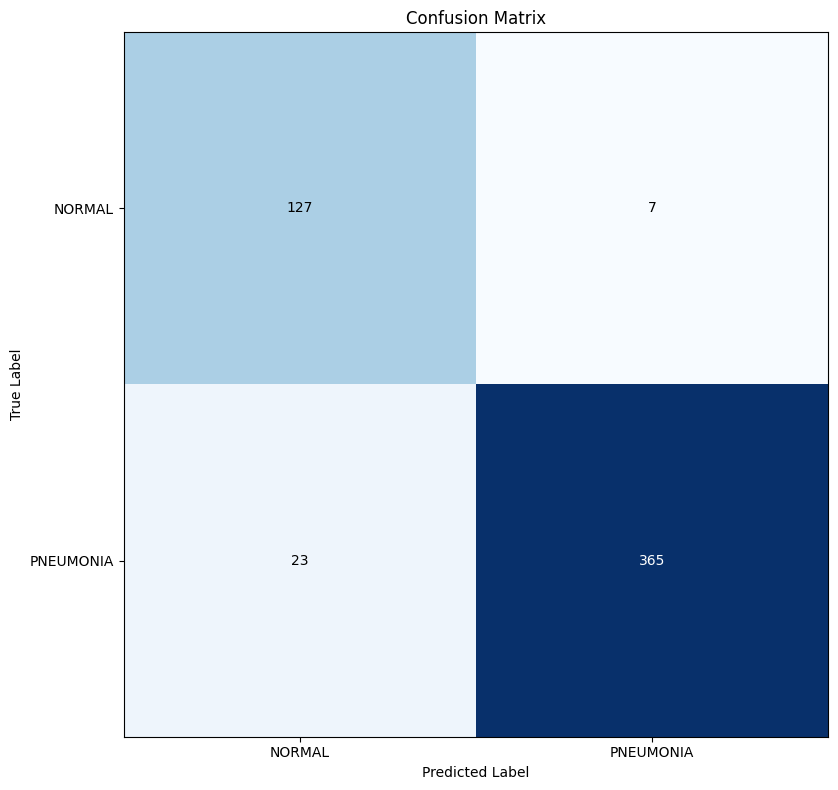

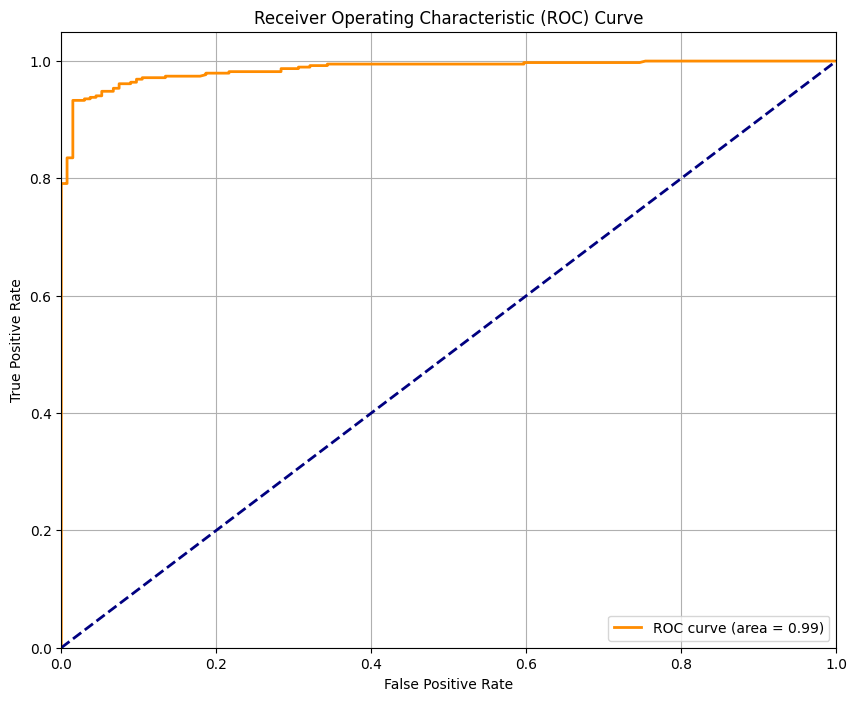

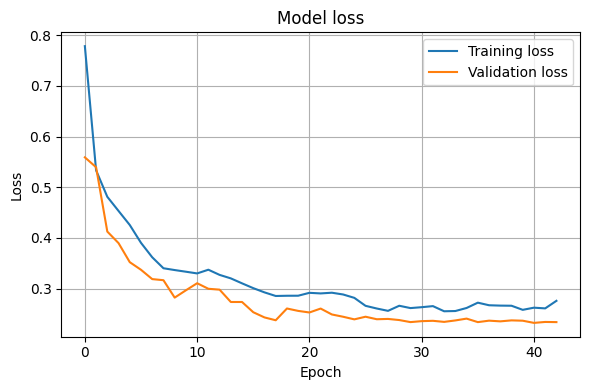

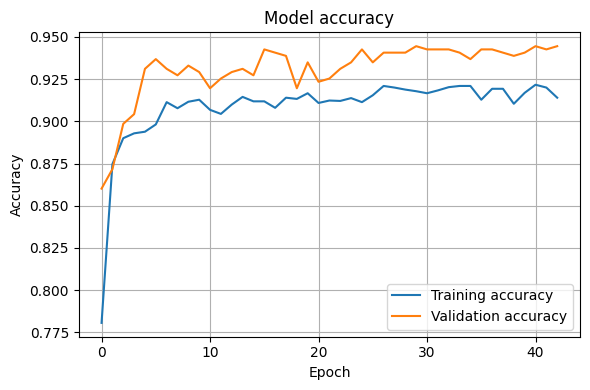

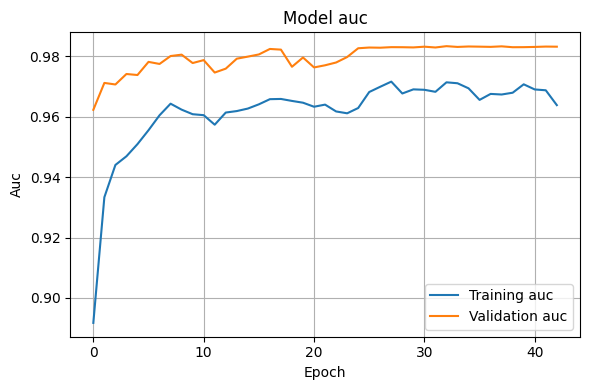

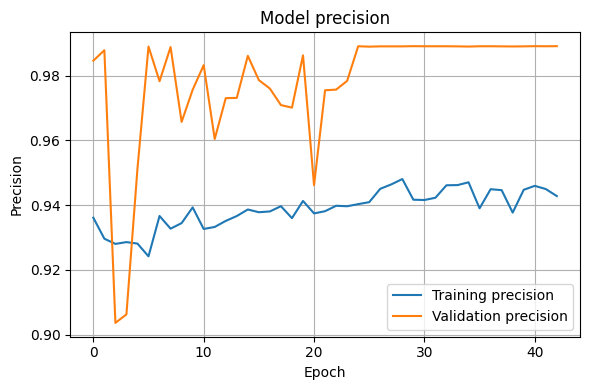

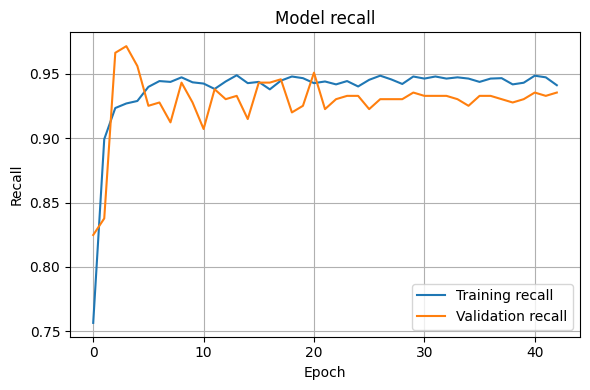

In [ ]:
evaluation = evaluate_model_improved(model, test_dataset, eval_output_dir)

# Plot and save each metric separately
metrics = ['loss', 'accuracy', 'auc', 'precision', 'recall']

for metric in metrics:
    plt.figure(figsize=(6, 4))
    plt.plot(history.history[metric], label=f'Training {metric}')
    plt.plot(history.history[f'val_{metric}'], label=f'Validation {metric}')
    plt.title(f'Model {metric}')
    plt.ylabel(metric.capitalize())
    plt.xlabel('Epoch')
    plt.legend(loc='best')
    plt.grid(True)
    plt.tight_layout()

    # Save each plot individually
    filename = f"training_history_{metric}.png"
    plt.savefig(os.path.join(output_dir, filename), dpi=200)
    plt.show()  # Show the plot inline (optional, remove if not needed)


In [ ]:
evaluation = evaluate_model_improved(model, test_dataset, eval_output_dir)

# Plot and save each metric separately
metrics = ['loss', 'accuracy', 'auc', 'precision', 'recall']

for metric in metrics:
    plt.figure(figsize=(6, 4))
    plt.plot(history.history[metric], label=f'Training {metric}')
    plt.plot(history.history[f'val_{metric}'], label=f'Validation {metric}')
    plt.title(f'Model {metric}')
    plt.ylabel(metric.capitalize())
    plt.xlabel('Epoch')
    plt.legend(loc='best')
    plt.grid(True)
    plt.tight_layout()

    # Save each plot individually
    filename = f"training_history_{metric}.png"
    plt.savefig(os.path.join(output_dir, filename), dpi=200)
    plt.show()  # Show the plot inline (optional, remove if not needed)



NameError: name 'evaluate_model_improved' is not defined